<a href="https://colab.research.google.com/github/gabriel-tfg/Practica2_ARP/blob/main/4_3_breakout_atari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q "gymnasium[atari,accept-rom-license]" ale-py autorom[accept-rom-license] "stable-baselines3[extra]"
!AutoROM --accept-license

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 11.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 17.4 MB/s eta 0:00:00
AutoROM will download the Atari 2600 ROMs.
They will be installed to:
	/usr/local/lib/python3.12/dist-packages/AutoROM/roms

Existing ROMs will be overwritten.


2. Librerías

In [ ]:
import os
import cv2
import ale_py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack, VecVideoRecorder
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback

from IPython.display import HTML
from base64 import b64encode

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


3. Configuración del entorno

In [ ]:
gym.register_envs(ale_py)

ENV_ID = "ALE/Breakout-v5"

test_env = gym.make(ENV_ID)
print("Entorno:", ENV_ID)
print("Espacio de observaciones:", test_env.observation_space)
print("Espacio de acciones:", test_env.action_space)
test_env.close()

Entorno: ALE/Breakout-v5
Espacio de observaciones: Box(0, 255, (210, 160, 3), uint8)
Espacio de acciones: Discrete(4)


4. Creación de entornos de entrenamiento y evaluación

In [ ]:
def create_env(n_envs=4):
    """
    Crea entornos Atari vectorizados y apilados.
    El apilado de frames permite que el agente perciba movimiento.
    """
    env = make_atari_env(
        ENV_ID,
        n_envs=n_envs,
        seed=42
    )
    env = VecFrameStack(env, n_stack=4)
    return env


train_env = create_env(n_envs=4)
eval_env = create_env(n_envs=1)

5. Crear modelo PPO

In [ ]:
model = PPO(
    "CnnPolicy",
    train_env,
    verbose=1,
    learning_rate=2.5e-4,
    n_steps=128,
    batch_size=256,
    n_epochs=4,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.1,
    ent_coef=0.01
)

Using cuda device
Wrapping the env in a VecTransposeImage.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


6. Callback de evaluación

In [ ]:
log_dir = "logs_breakout"
os.makedirs(log_dir, exist_ok=True)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=log_dir,
    log_path=log_dir,
    eval_freq=10_000,
    n_eval_episodes=5,
    deterministic=True,
    render=False
)

7. Entrenamiento

In [ ]:
TOTAL_TIMESTEPS = 500_000

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=eval_callback
)

model.save("ppo_breakout_model")

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/callbacks.py:419: UserWarning: Training and eval env are not of the same type<stable_baselines3.common.vec_env.vec_transpose.VecTransposeImage object at 0x7c1361d43aa0> != <stable_baselines3.common.vec_env.vec_frame_stack.VecFrameStack object at 0x7c1364ba60c0>
  warnings.warn("Training and eval env are not of the same type" f"{self.training_env} != {self.eval_env}")


Se han truncado las últimas 5000 líneas del flujo de salida.
|    iterations           | 741          |
|    time_elapsed         | 1748         |
|    total_timesteps      | 379392       |
| train/                  |              |
|    approx_kl            | 0.0022969432 |
|    clip_fraction        | 0.0571       |
|    clip_range           | 0.1          |
|    entropy_loss         | -0.239       |
|    explained_variance   | 0.816        |
|    learning_rate        | 0.00025      |
|    loss                 | 0.0809       |
|    n_updates            | 2960         |
|    policy_gradient_loss | -0.00472     |
|    value_loss           | 0.216        |
------------------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 772          |
|    ep_rew_mean          | 21.3         |
| time/                   |              |
|    fps                  | 216          |
|    iterations           | 742     

8. Carga de mejor modelo

In [ ]:
best_model_path = "logs_breakout/best_model.zip"

if os.path.exists(best_model_path):
    model = PPO.load(best_model_path, env=eval_env)
    print("Mejor modelo cargado.")
else:
    print("No se encontró best_model.zip. Se usará el modelo final.")

Wrapping the env in a VecTransposeImage.
Mejor modelo cargado.


9. Evaluación cuantitativa

In [ ]:
mean_reward, std_reward = evaluate_policy(
    model,
    eval_env,
    n_eval_episodes=10,
    deterministic=True
)

print("Recompensa media:", mean_reward)
print("Desviación típica:", std_reward)

Recompensa media: 22.8
Desviación típica: 5.509990925582365


10. Evaluación episodio por episodio

In [ ]:
episode_rewards = []

for ep in range(10):
    single_env = make_atari_env(
        ENV_ID,
        n_envs=1,
        seed=100 + ep
    )
    single_env = VecFrameStack(single_env, n_stack=4)

    obs = single_env.reset()
    done = False
    total_reward = 0

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, info = single_env.step(action)
        total_reward += float(reward[0])

    episode_rewards.append(total_reward)
    single_env.close()

    print(f"Episodio {ep+1}: {total_reward}")

episode_df = pd.DataFrame({
    "Episodio": np.arange(1, 11),
    "Recompensa": episode_rewards
})

episode_df

Episodio 1: 4.0
Episodio 2: 8.0
Episodio 3: 6.0
Episodio 4: 8.0
Episodio 5: 8.0
Episodio 6: 4.0
Episodio 7: 2.0
Episodio 8: 4.0
Episodio 9: 5.0
Episodio 10: 4.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Episodio,Recompensa
0,1,4.0
1,2,8.0
2,3,6.0
3,4,8.0
4,5,8.0
5,6,4.0
6,7,2.0
7,8,4.0
8,9,5.0
9,10,4.0


11. Gráfica de recompensas por episodio

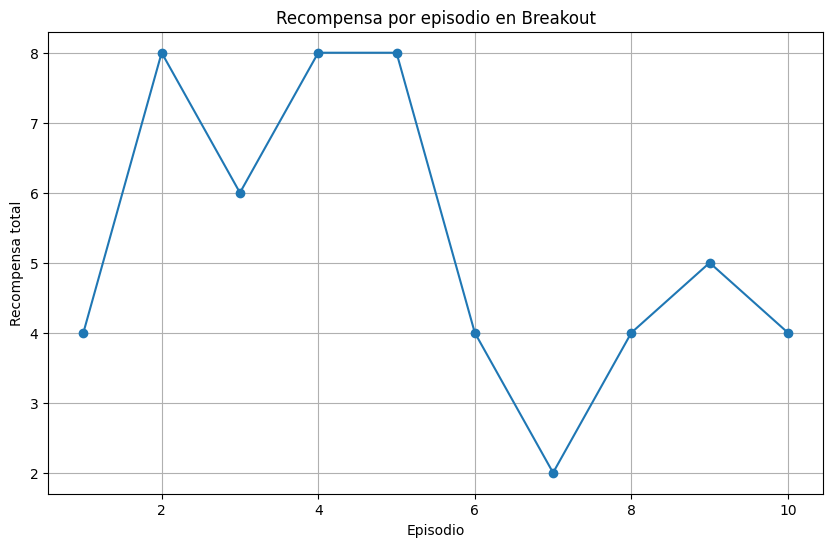

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(episode_df["Episodio"], episode_df["Recompensa"], marker="o")
plt.xlabel("Episodio")
plt.ylabel("Recompensa total")
plt.title("Recompensa por episodio en Breakout")
plt.grid(True)
plt.show()

plt.savefig("breakout_recompensas_episodio.png", bbox_inches="tight")

12. Gráfica de evolución del entrenamiento

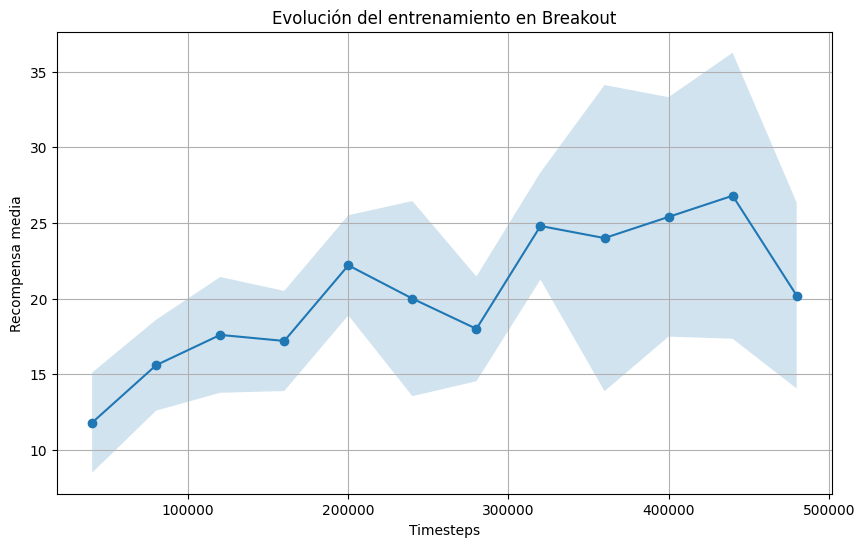

<Figure size 640x480 with 0 Axes>

In [ ]:
eval_path = "logs_breakout/evaluations.npz"

if os.path.exists(eval_path):
    data = np.load(eval_path)
    timesteps = data["timesteps"]
    results = data["results"]

    mean_rewards = results.mean(axis=1)
    std_rewards = results.std(axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(timesteps, mean_rewards, marker="o")
    plt.fill_between(
        timesteps,
        mean_rewards - std_rewards,
        mean_rewards + std_rewards,
        alpha=0.2
    )
    plt.xlabel("Timesteps")
    plt.ylabel("Recompensa media")
    plt.title("Evolución del entrenamiento en Breakout")
    plt.grid(True)
    plt.show()

    plt.savefig("breakout_evolucion_entrenamiento.png", bbox_inches="tight")
else:
    print("No se encontró el archivo de evaluaciones.")

13. Grabar vídeo del agente

In [ ]:
video_folder = "videos_breakout"
os.makedirs(video_folder, exist_ok=True)

video_env = make_atari_env(
    ENV_ID,
    n_envs=1,
    seed=123
)
video_env = VecFrameStack(video_env, n_stack=4)

video_env = VecVideoRecorder(
    video_env,
    video_folder,
    record_video_trigger=lambda x: x == 0,
    video_length=3000,
    name_prefix="breakout_ppo_long"
)

obs = video_env.reset()
total_reward = 0
episode_rewards = []
current_episode_reward = 0

for step in range(3000):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = video_env.step(action)

    r = float(reward[0])
    total_reward += r
    current_episode_reward += r

    # Si termina el episodio, reiniciamos pero seguimos grabando
    if done:
        episode_rewards.append(current_episode_reward)
        current_episode_reward = 0
        obs = video_env.reset()

video_env.close()

print("Recompensa total del vídeo:", total_reward)
print("Recompensas por episodio dentro del vídeo:", episode_rewards)

Saving video to /content/videos_breakout/breakout_ppo_long-step-0-to-step-3000.mp4


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Moviepy - Building video /content/videos_breakout/breakout_ppo_long-step-0-to-step-3000.mp4.
Moviepy - Writing video /content/videos_breakout/breakout_ppo_long-step-0-to-step-3000.mp4



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
                                                                 

Moviepy - Done !
Moviepy - video ready /content/videos_breakout/breakout_ppo_long-step-0-to-step-3000.mp4
Recompensa total del vídeo: 254.0
Recompensas por episodio dentro del vídeo: [4.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 0.0, 0.0, 4.0, 0.0, 3.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 5.0, 0.0, 0.0, 0.0, 4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0.0, 0.0, 4.0, 0.0, 0.0, 4.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.0, 0

14. Visualizar vídeo

In [ ]:
video_files = [f for f in os.listdir(video_folder) if f.endswith(".mp4")]
video_files

['breakout_ppo_long-step-0-to-step-3000.mp4']

In [ ]:
video_path = os.path.join(video_folder, video_files[0])

mp4 = open(video_path, "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=800 controls>
    <source src="{data_url}" type="video/mp4">
</video>
""")

15. Guardar resultados

In [ ]:
summary_df = pd.DataFrame({
    "Entorno": [ENV_ID],
    "Algoritmo": ["PPO"],
    "Timesteps": [TOTAL_TIMESTEPS],
    "Recompensa media": [mean_reward],
    "Desviación típica": [std_reward],
    "Recompensa vídeo": [total_reward]
})

summary_df.to_csv("breakout_summary.csv", index=False)
episode_df.to_csv("breakout_episode_rewards.csv", index=False)

summary_df

,Entorno,Algoritmo,Timesteps,Recompensa media,Desviación típica,Recompensa vídeo
0,ALE/Breakout-v5,PPO,500000,22.8,5.509991,254.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
